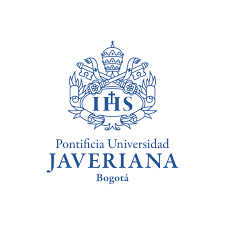
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

**Autor:** Ian Tomas Felipe Fonseca Coronado


### Taller: **Clasificación y métricas de aprendizaje en data set de banco**

Fecha actual: 06/05/2026

### Dataset information
### Additional Information

The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed. 

There are four datasets: 
1) bank-additional-full.csv with all examples (41188) and 20 inputs, ordered by date (from May 2008 to November 2010), very close to the data analyzed in [Moro et al., 2014]
2) bank-additional.csv with 10% of the examples (4119), randomly selected from 1), and 20 inputs.
3) bank-full.csv with all examples and 17 inputs, ordered by date (older version of this dataset with less inputs). 
4) bank.csv with 10% of the examples and 17 inputs, randomly selected from 3 (older version of this dataset with less inputs). 
The smallest datasets are provided to test more computationally demanding machine learning algorithms (e.g., SVM). 

The classification goal is to predict if the client will subscribe (yes/no) a term deposit (variable y).

### **1.-Importación de Bibliotecas y Sesión Spark**

In [1]:
## Importar bibliotecas de uso General 
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
### Importar bibliotecas de uso especifícos 

##Importacion de la funcion para
import findspark
findspark.init()
from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession


In [3]:
### Se requiere levantar la sesion para trabjar con los servicios
### Basados en SPARK: procesamiento paralelo y distribuido sobre Grandes Volumenes de Datos
configura = SparkConf()
configura.setAppName("BankClasification")
sparkFonseca = SparkSession.builder.config(conf=configura).getOrCreate()
sparkFonseca


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/23 21:34:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv/bank-full.csv

/bin/bash: line 1: /mnt/sda1/Cluster/Hadoop/bin/hadoop: No such file or directory


In [5]:
df00 = sparkFonseca.read.format("csv").option("sep",";").option("header","true").load("bank-full.csv")
# Se presenta las primeras filas 
df00.show(5)

[Stage 1:>                                                          (0 + 1) / 1]

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

### 2. Analisis de variables y corrección de tipos de datos.

In [6]:
df00.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

### Tabla de variables del dataset 
Enlace: https://archive.ics.uci.edu/dataset/222/bank+marketing

In [7]:
#### REvision de tipos de datos
df00.printSchema()

root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



### Comentario/Observaciones
- Hasta este punto se puede observar que los tipos de datos no corresponden a los datos tal cual.
- Todas las columnas contiene datos de tipo string, y el priblema es que varias, como 'age' y 'balance', son variables de valores numericos.
- Se debe realizar un cambio de tipo de datos acorde a como estan determinados los datos en la pagina de origen de los datos.

In [8]:
## Cambiar las variables correspondientes a datos tipo entero
nombreColumnas = ['age', 'job', 'marital',
                   'education', 'default', 'balance',
                   'housing', 'loan', 'contact',
                   'day', 'month', 'duration',
                   'campaign', 'pdays', 'previous',
                   'poutcome', 'y']
columnas_Int = ['age', 'balance', 'day', 'duration','campaign', 'pdays', 'previous']

#Se hace el casting a entero
df01=df00.withColumn("age", df00.age.cast("int"))
df01=df01.withColumn("balance", df00.balance.cast("int"))
df01=df01.withColumn("day", df00.day.cast("int"))
df01=df01.withColumn("duration", df00.duration.cast("int"))
df01=df01.withColumn("campaign", df00.campaign.cast("int"))
df01=df01.withColumn("pdays", df00.pdays.cast("int"))
df01=df01.withColumn("previous", df00.previous.cast("int"))
### Revisamos el cambio de tipo de dato.
df01.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [9]:
## Se muestran las diez primeras filas del dataframe Spark
df01.show(10)

+---+------------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job| marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management| married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician|  single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur| married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar| married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown|  single|  unknown|     no|      1|     no|  no|unknown|  5|  may

### **Comentarios**
- Despues de hacer el cambio de los datos númericos de string a int se pueden ver a plena vista que algunos son costantes y tiene siempre el mismo valos, mientras que otros varian demasiado unas de otras.
- Otra cosa que se puede ver es que la variable 'y' la variable dependiente, la que nos dice si la persona se ha o no suscrito a un deposito a plazo, es una variable binaria.
- Se deben hacer analisis para determinar la dispersion de la variable dependiente y los valores númericos.

### **3.-Graficas de analisis**

In [10]:
### Balanceo de la variable y

cantTotal = df00.count()
cantY = df00.groupBy("y").count()
y= df00.groupBy("y")
print(f"cantidad total de registros del dataset = {cantTotal} sin exahustivo EDA\n")

# Tabla pra presentar el porcentaje de la variable binaria Y (Variable Dependiente)
dfAUX = cantY.withColumn("Porcentaje", cantY["count"]*100/cantTotal)
Porcentaje = cantY["count"]*100/cantTotal
#dfAUX.show()
dfAUX.toPandas().head()

cantidad total de registros del dataset = 45211 sin exahustivo EDA



,y,count,Porcentaje
0,no,39922,88.30152
1,yes,5289,11.69848


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

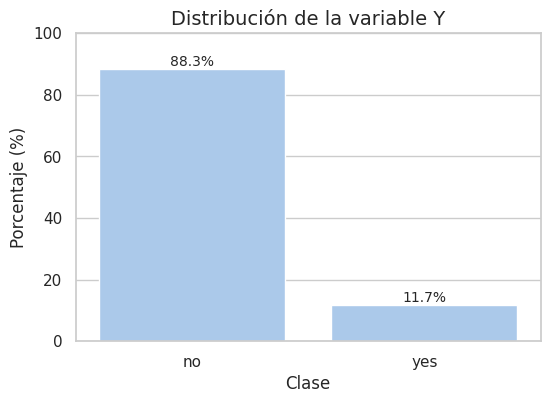

In [12]:
df_plot = dfAUX.toPandas()

sns.set(style="whitegrid", palette="pastel")

plt.figure(figsize=(6,4))
ax = sns.barplot(data=df_plot, x="y", y="Porcentaje")
for i, row in df_plot.iterrows():
    ax.text(i, row["Porcentaje"] + 1, f"{row['Porcentaje']:.1f}%", 
            ha='center', fontsize=10)

plt.title("Distribución de la variable Y", fontsize=14)
plt.xlabel("Clase")
plt.ylabel("Porcentaje (%)")

plt.ylim(0, 100)
plt.show()

### **Comentarios**
- Despues de analisar y sacar la distribución se puede decir que la mayor parte de las personas entrevistadas no tiene una suscripcion a un deposito a plazo.
- Directamente se presenta una diferencia del 88.3% que dice que no, contra un 11.7% que dice si.

_______________________________________________________________________________________________________________________________________________________

In [13]:
### Estudio y analisis sobre las variables independientes
df01.describe().toPandas().head()

26/05/23 21:34:44 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


In [14]:
# Convertimos el describe() de PySpark a Pandas

summary_df = df01.describe().toPandas()

# Mostramos la tabla
summary_df

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


In [15]:
# Lista de columnas numéricas que sí podemos graficar

numeric_columns = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

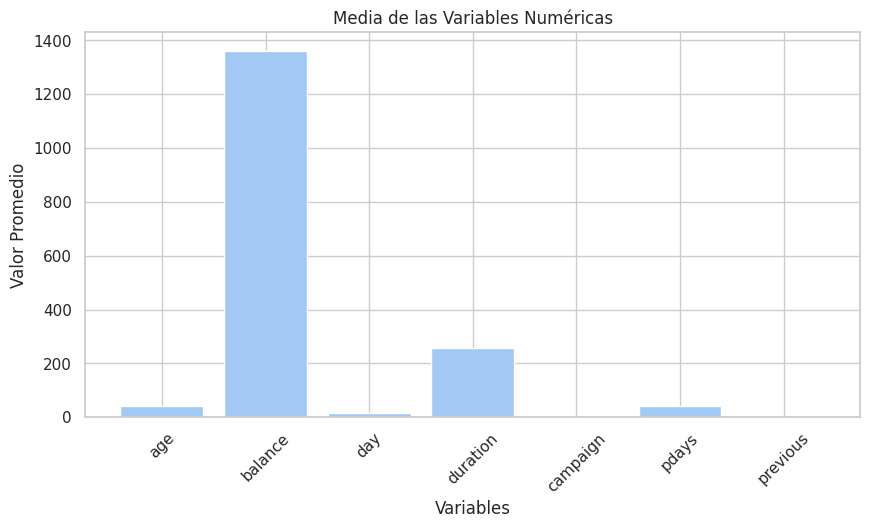

In [16]:
# Seleccionamos la fila donde están las medias

mean_data = summary_df[summary_df['summary'] == 'mean']

# Convertimos los valores a números
mean_values = mean_data[numeric_columns].astype(float).iloc[0]

# Creamos la gráfica
plt.figure(figsize=(10,5))

plt.bar(numeric_columns, mean_values)

# Título y nombres
plt.title('Media de las Variables Numéricas')
plt.xlabel('Variables')
plt.ylabel('Valor Promedio')

# Rotamos nombres para que se vean mejor
plt.xticks(rotation=45)

# Mostramos la gráfica
plt.show()

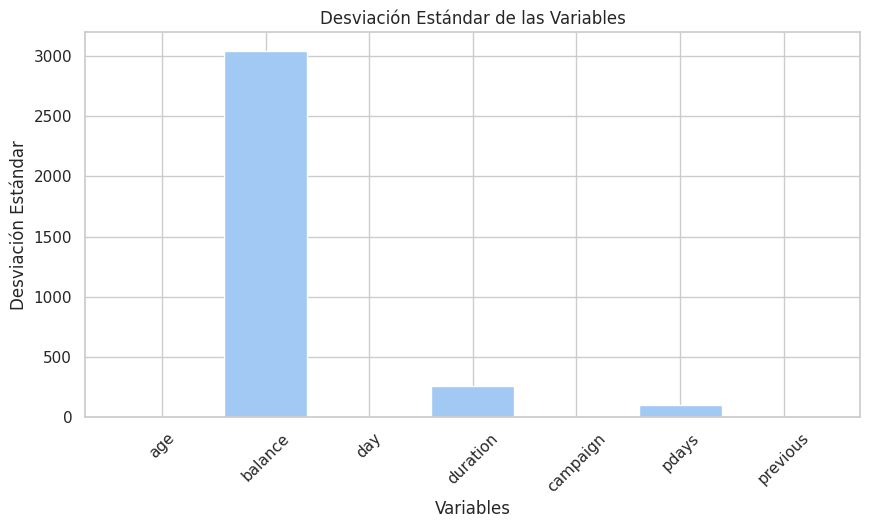

In [17]:
# Seleccionamos la fila de desviación estándar

std_data = summary_df[summary_df['summary'] == 'stddev']

# Convertimos a números
std_values = std_data[numeric_columns].astype(float).iloc[0]

# Creamos la gráfica
plt.figure(figsize=(10,5))

plt.bar(numeric_columns, std_values)

# Título y etiquetas
plt.title('Desviación Estándar de las Variables')
plt.xlabel('Variables')
plt.ylabel('Desviación Estándar')

# Rotamos nombres
plt.xticks(rotation=45)

# Mostramos la gráfica
plt.show()

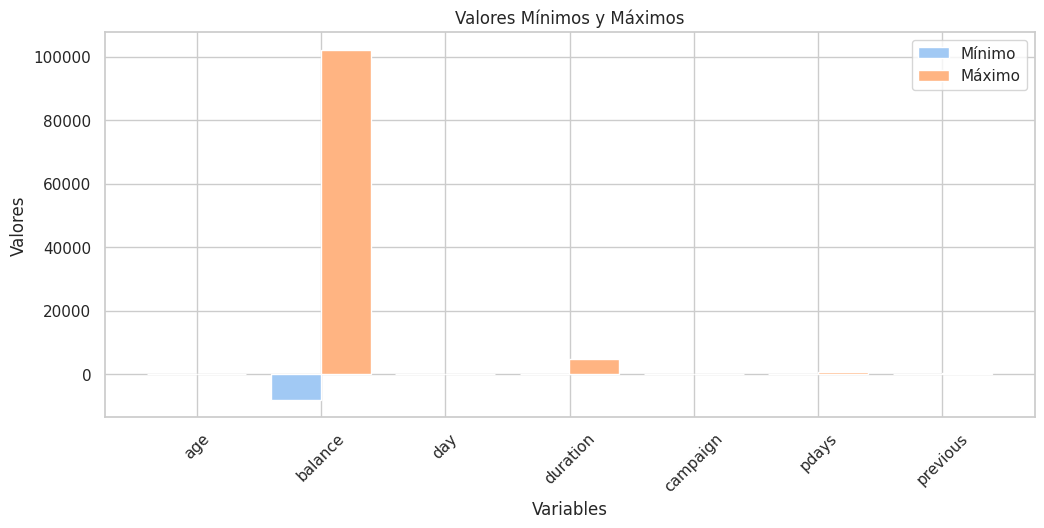

In [18]:
# Seleccionamos mínimos y máximos

min_data = summary_df[summary_df['summary'] == 'min']
max_data = summary_df[summary_df['summary'] == 'max']

# Convertimos a números
min_values = min_data[numeric_columns].astype(float).iloc[0]
max_values = max_data[numeric_columns].astype(float).iloc[0]

# Posiciones para las barras
x = range(len(numeric_columns))

# Tamaño de la gráfica
plt.figure(figsize=(12,5))

# Barras de mínimos
plt.bar(x, min_values, width=0.4, label='Mínimo')

# Barras de máximos desplazadas
plt.bar(
    [i + 0.4 for i in x],
    max_values,
    width=0.4,
    label='Máximo'
)

# Etiquetas
plt.title('Valores Mínimos y Máximos')
plt.xlabel('Variables')
plt.ylabel('Valores')

# Nombres de columnas
plt.xticks([i + 0.2 for i in x], numeric_columns, rotation=45)

# Leyenda
plt.legend()

# Mostrar gráfica
plt.show()

### **Comentarios**
- Al realizar un análisis más profundo de la base de datos, se decidió crear tres gráficas para complementar la información obtenida.
- La primera gráfica se centra en mostrar la media de todos los datos numéricos, la segunda en sus desviaciones estándar y la tercera en los valores máximos y mínimos. A partir de estas gráficas, se puede deducir que la columna Balance contiene los valores numéricos más altos, lo que podría afectar el análisis del resto de los datos. Sin embargo, en este caso, este tipo de comportamiento es precisamente uno de los aspectos que se busca analizar.

_______________________________________________________________________________________________________________________________________________________

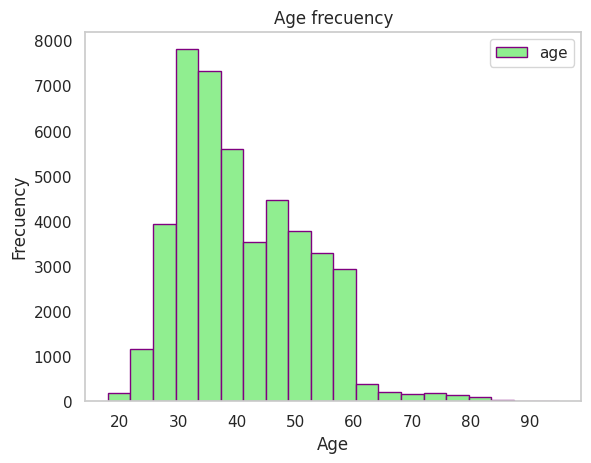

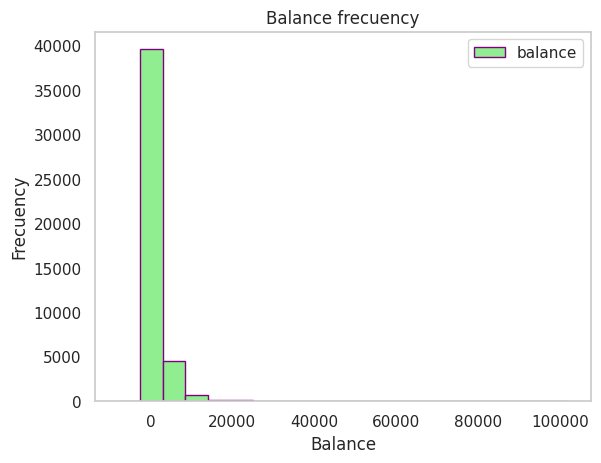

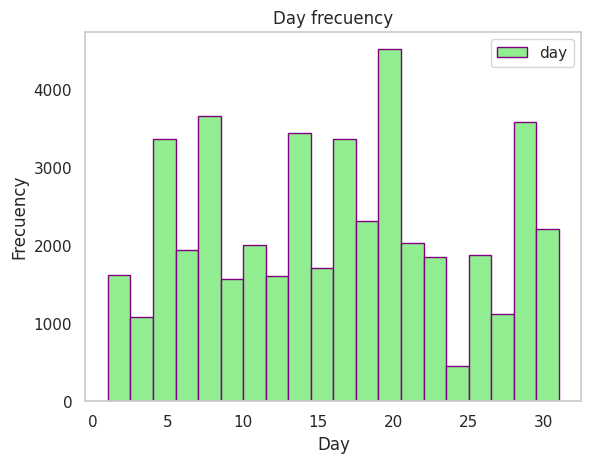

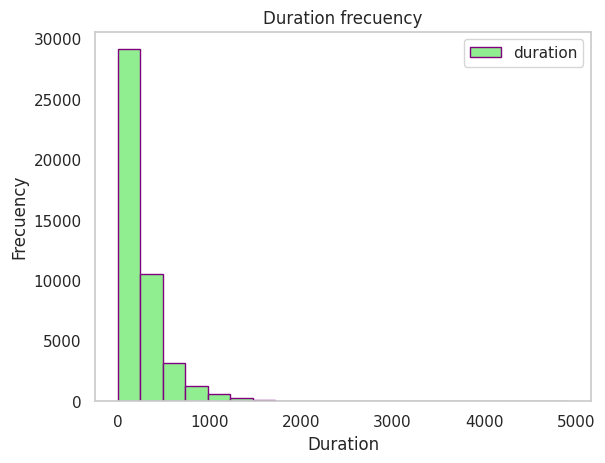

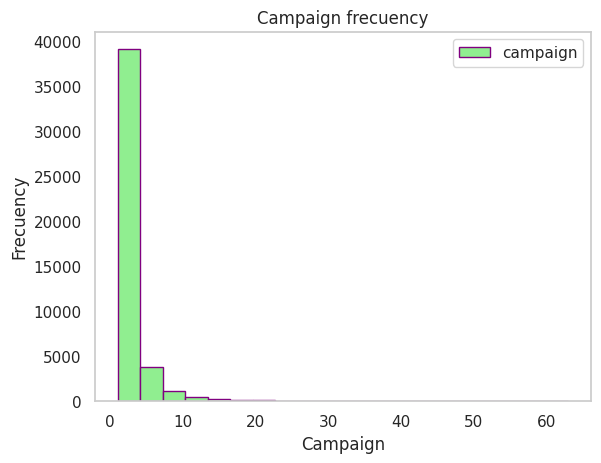

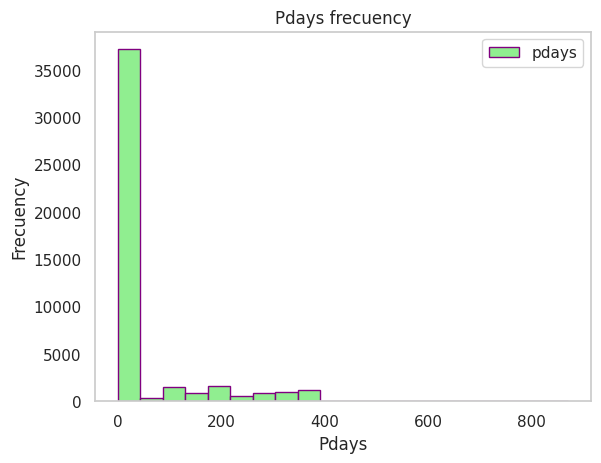

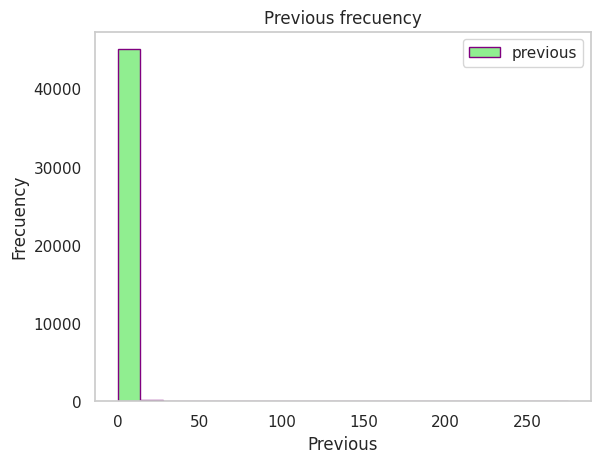

In [19]:
for nombreColumnas in columnas_Int:
    histGra = df01.select(nombreColumnas).toPandas()
    histGra.plot(kind="hist", bins=20, edgecolor='purple', color='lightgreen')
    plt.ylabel("Frecuency")
    plt.xlabel(nombreColumnas.capitalize())
    plt.title(f"{nombreColumnas.capitalize()} frecuency")
    plt.grid()
    plt.show()

### **Comentarios**
- Para continuar con los análisis se realizó un ciclo para crear gráficos que complementen lo que se sabe hasta ahora de las variables numéricas.
- Estas gráficas se centran en mostrar la frecuencia con la que una de estas variables presenta un valor, por ejemplo, qué tan frecuente es que las personas tengan 20 años.
- De las gráficas se puede resaltar que casi todas las columnas exceptuando a “age” y “day” se centran en valores bajos, eso quiere decir que la mayoría de los datos están centrados valores bajos, por ejemplo “duration” indica que los contactos con las personas en su mayoría duraron 0 segundos.


_______________________________________________________________________________________________________________________________________________________

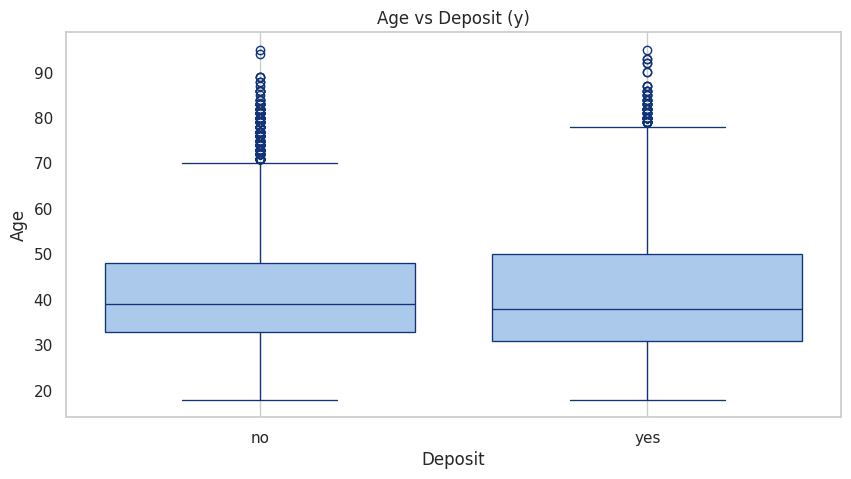

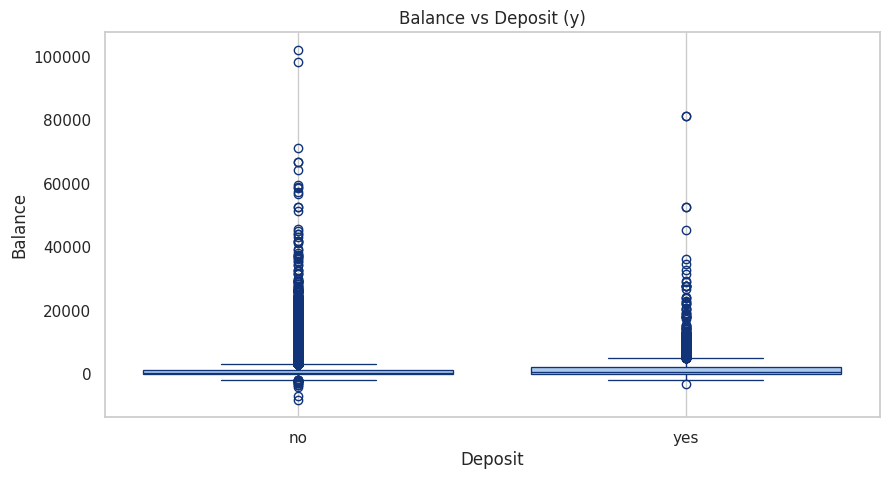

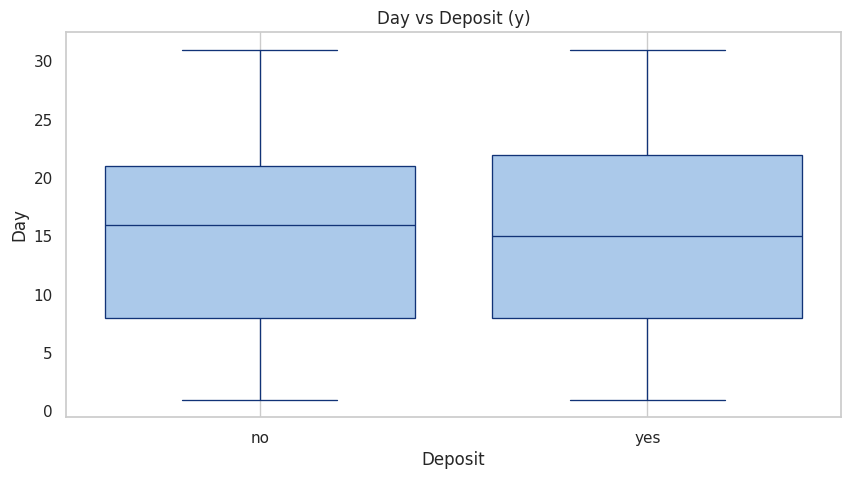

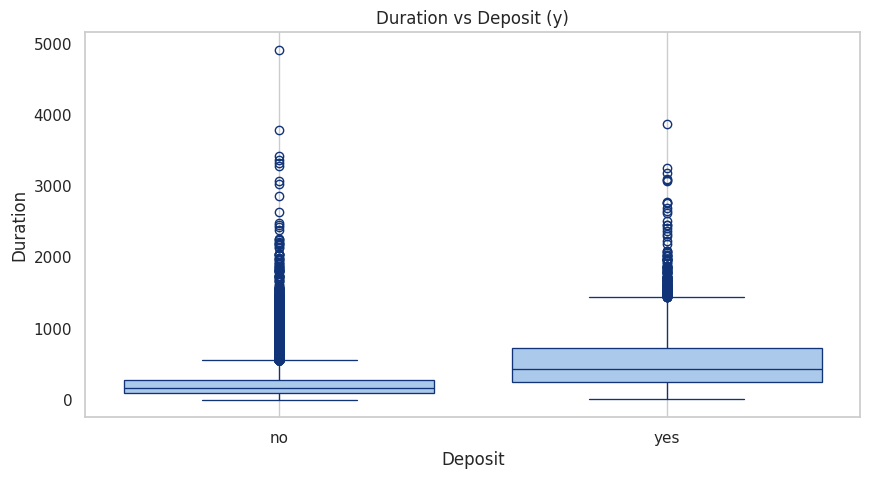

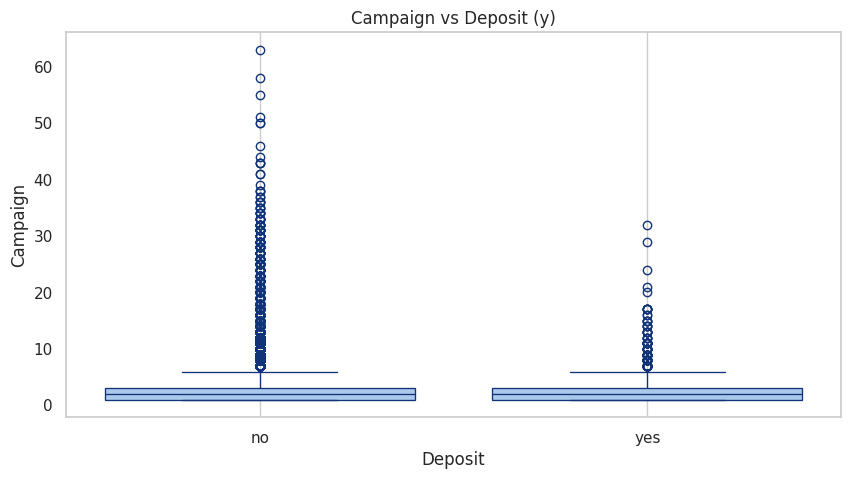

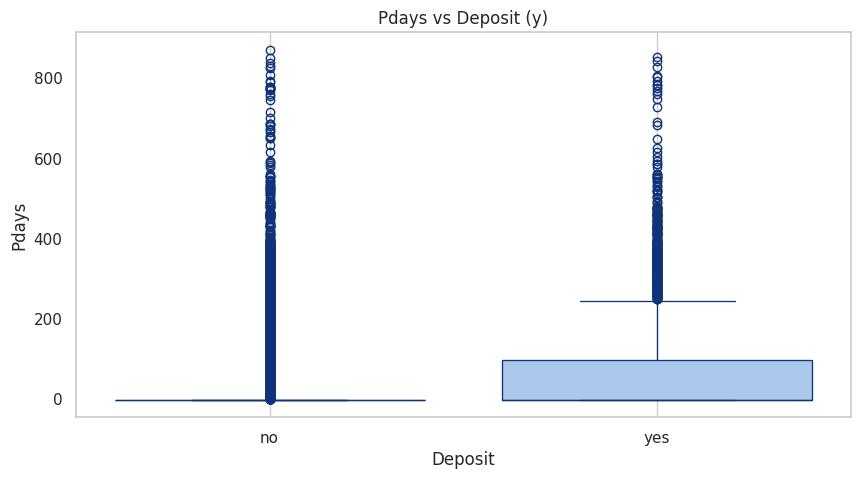

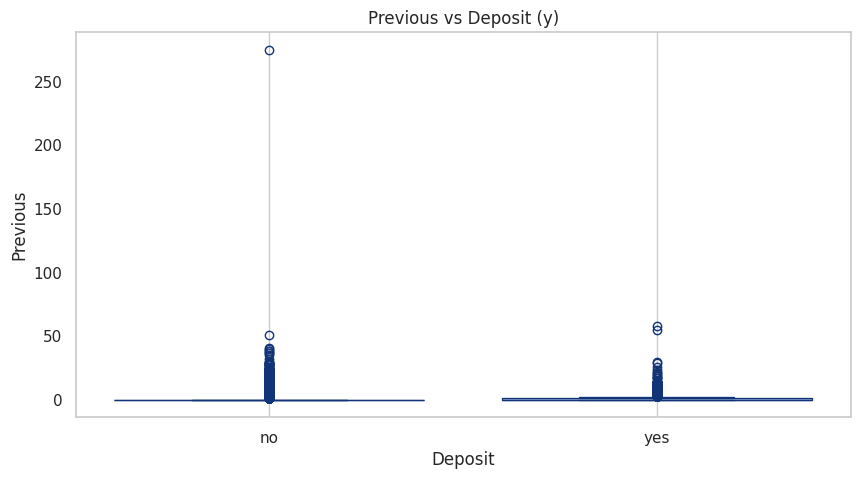

In [20]:
for nombreColumnas in columnas_Int:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='y', y=nombreColumnas, linecolor="#137", linewidth=0.95, data=df01.toPandas())
    plt.title(f"{nombreColumnas.capitalize()} vs Deposit (y)")
    plt.xlabel("Deposit")
    plt.ylabel(nombreColumnas.capitalize())
    plt.grid()
    plt.show()

### **Comentarios**
- Para continuar con los análisis se realizó un ciclo para crear gráficos que complementen lo que se sabe hasta ahora de las variables numéricas.
- Estas gráficas de cajas se centran en mostrar la comparación entre la media de cada variable aleatoria relacionada con los valores de la variable dependiente.
- Se puede identificar que en la mayoria de los casos la media es casi igual sin importar el valor de la variable dependiente, aunque se ve que el rango cercano a la media tiende a ser siempre mas grande cuando la variable dependiente es yes. Finalmente, se puede evidenciar que existen muchos datos atipicos.

_______________________________________________________________________________________________________________________________________________________

In [21]:
from pyspark.sql import functions as F
colNum = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

dfauxNum = df01.select(colNum + ["y"])
dfauxNum = dfauxNum.withColumn('y', F.when(dfauxNum['y'] == 'yes',1).otherwise(0))
dfauxNum.show(5)

+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



In [22]:
dfauxNum.printSchema()

root
 |-- age: integer (nullable = true)
 |-- balance: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- y: integer (nullable = false)



In [23]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation

ensamblador = VectorAssembler(inputCols=dfauxNum.columns, outputCol='features')
# Normalizado y Escalado
dfNumVector = ensamblador.transform(dfauxNum).select('features')

### **Comentarios**
- En esta sección se hace la transformación de la variable dependiente de binario a integral, con el fin de hacer analisis.

_______________________________________________________________________________________________________________________________________________________

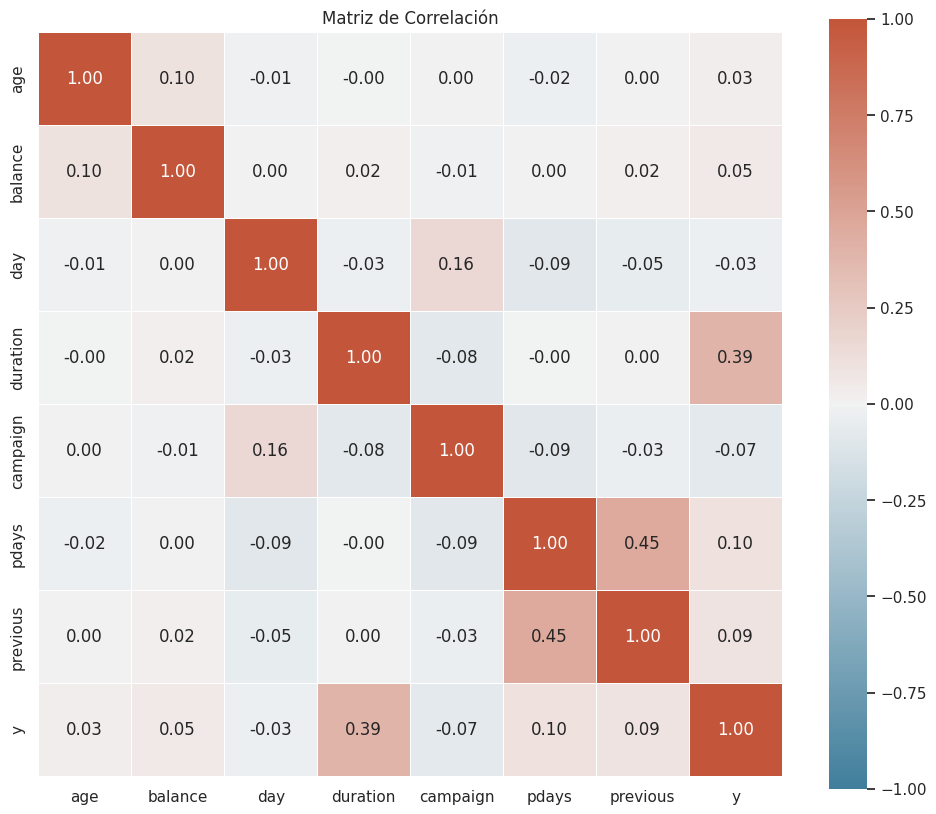

In [24]:
matrizCorr = Correlation.corr(dfNumVector, 'features').head()
vectorCorr = matrizCorr[0].toArray()

dfCorrelacion = pd.DataFrame(vectorCorr, columns=dfauxNum.columns, index=dfauxNum.columns)

plt.figure(figsize=(12, 10))
sns.heatmap(dfCorrelacion, annot=True, fmt=".2f", 
            cmap=sns.diverging_palette(230, 20, as_cmap=True), 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title("Matriz de Correlación")
plt.show()

### **Comentarios**
- En el mapa de calor se puede ver que en general todas las variables tiene una correlación baja con escepción de 4: La variable dependiente 'y' tiene una correlación con duratiojn de 0.39. Y pdays tiene una relación con previous de 0.45.

_______________________________________________________________________________________________________________________________________________________

<function matplotlib.pyplot.show(close=None, block=None)>

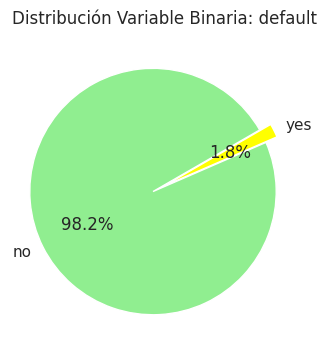

In [25]:
explode = (0.1, 0)
colors = ['lightgreen', 'yellow']
plt.figure(figsize=(5,4))
cantBin = df01.groupBy('default').count().toPandas()
cantBin.set_index('default')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=30)
plt.title(f'Distribución Variable Binaria: default')
plt.ylabel('')
plt.show

### **Comentarios**
- Tomamos la variable default, que es binaria, la cual determina si una persona tiene o no su credito en Mora.
- En esta grafica se ve la proporción en porcentaje de personas que tienen o no tienen su credito en mora y se puede decir que solo el 1.8% lo tiene en mora. Por lo que la mayor parte de los clientes son cumplidos con sus pagos.

_______________________________________________________________________________________________________________________________________________________

<Figure size 800x600 with 0 Axes>

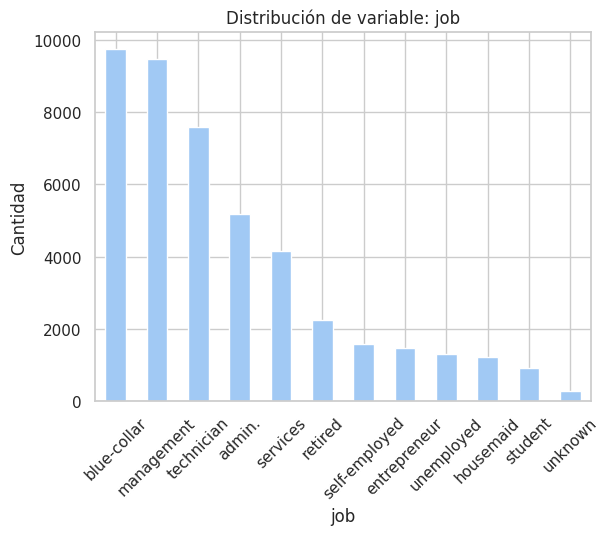

In [26]:
cantMulti = df01.groupBy('job').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
cantMulti.plot(kind='bar', x='job', y='count', legend=None)
plt.xlabel('job')
plt.ylabel('Cantidad')
plt.title(f'Distribución de variable: job')
plt.xticks(rotation=45)
plt.show()

### **Comentarios**
- Gracias a la grfica se puede afirmar que la moyor parte de la clientela del banco son personas que trabajan en la construcción y muy pocos son los que no han informado en que trabajan.

_______________________________________________________________________________________________________________________________________________________

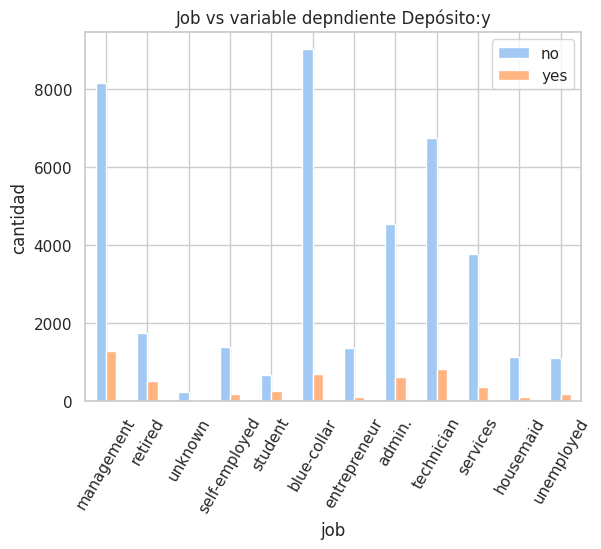

In [27]:
cratabjob= df01.crosstab('job', 'y').toPandas()
cratabjob.set_index('job' + '_y').plot(kind='bar')
plt.xlabel('job')
plt.ylabel('cantidad')
plt.title('Job vs variable depndiente Depósito:y')
plt.xticks(rotation=60)
plt.show()

### **Comentarios**
- Segun la grafica, se puede ver que la cantidad de gente que no tiene suscribción a deposito a plazo, supera con creces a los que si tiene.
- En general los estudiantes son los que en relación con su cantidad total, tienen mas gente suscrita a deposito a plazo. Esto puede indicar que los estudiantes son los clientes mas dispuestos a tener depositos a plazo.

_______________________________________________________________________________________________________________________________________________________

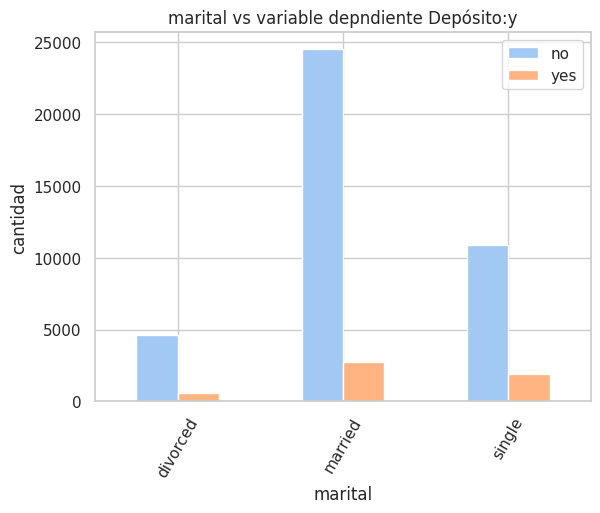

In [28]:
cratabmarital= df01.crosstab('marital', 'y').toPandas()
cratabmarital.set_index('marital' + '_y').plot(kind='bar')
plt.xlabel('marital')
plt.ylabel('cantidad')
plt.title('marital vs variable depndiente Depósito:y')
plt.xticks(rotation=60)
plt.show()

### **Comentarios**
- En esta grafica se puede ver que, en proporción, la mayor parte de los que tienen suscripción a deposito son los solteros. A pesar de que la mayor parte de los suscritos son casados.

_______________________________________________________________________________________________________________________________________________________

## **Comparativa entre las variables numericas y categoricas**

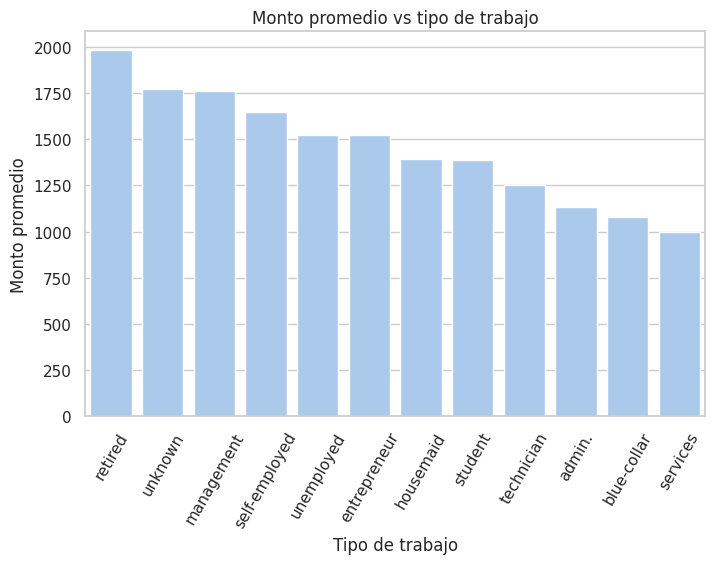

In [29]:
nomColumnas = ['age', 'job', 'marital',
                   'education', 'default', 'balance',
                   'housing', 'loan', 'contact',
                   'day', 'month', 'duration',
                   'campaign', 'pdays', 'previous',
                   'poutcome', 'y']


columnas_Int = ['age', 'balance', 'day', 'duration','campaign', 'pdays', 'previous']

# Se requiere graficar la relación del balance (monto promedio anual) por job (tipo de trabajo)
monto_trabajo = df01.groupBy('job').agg({'balance':'mean'}).toPandas()
## El promedio sobre el monto y el tipo de trbajo: se ordena de mayor a menos por monto
monto_trabajo = monto_trabajo.sort_values('avg(balance)', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=monto_trabajo, x='job', y='avg(balance)')
plt.xlabel('Tipo de trabajo')
plt.ylabel('Monto promedio')
plt.title('Monto promedio vs tipo de trabajo')
plt.xticks(rotation=60)
plt.show()

### **Comentarios**
- En esta grafica se ve la relación entre el tipo de trabajo del cliente y el monto promedio que ingresa al banco y, a pesar de que la mayoria de los clientes son de cuello azul o trabajo de construcción, el monto promedio mayos biene de los retirados.

_______________________________________________________________________________________________________________________________________________________

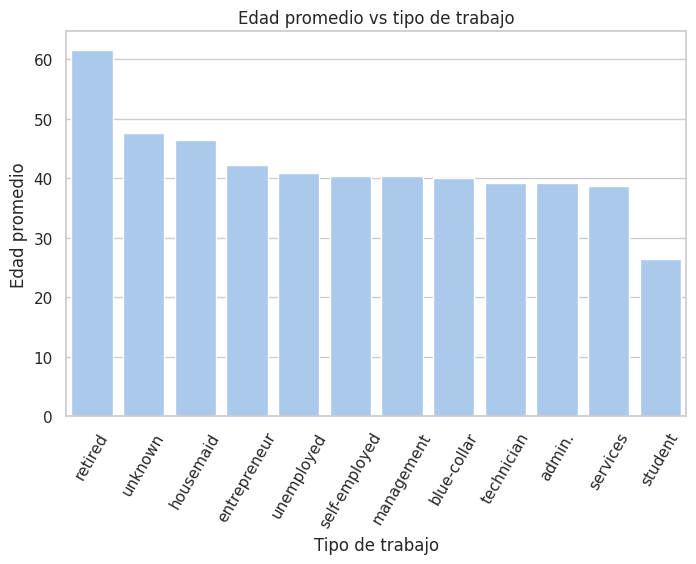

In [30]:
#Grafico Edad vs tipo de trabajo
edad_trabajo = df01.groupBy('job').agg({'age':'mean'}).toPandas()
## El promedio sobre el monto y el tipo de trbajo: se ordena de mayor a menos por monto
edad_trabajo = edad_trabajo.sort_values('avg(age)', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=edad_trabajo, x='job', y='avg(age)')
plt.xlabel('Tipo de trabajo')
plt.ylabel('Edad promedio')
plt.title('Edad promedio vs tipo de trabajo')
plt.xticks(rotation=60)
plt.show()

### **Comentarios**
- Relacionado con la anterior grafíca ahora se hace una grafica que compara el tipo de trabajo y la edad promedio y, como era de esperarse, los retirados tienden a tener mayor edad y los estudiantes la menor.

_______________________________________________________________________________________________________________________________________________________

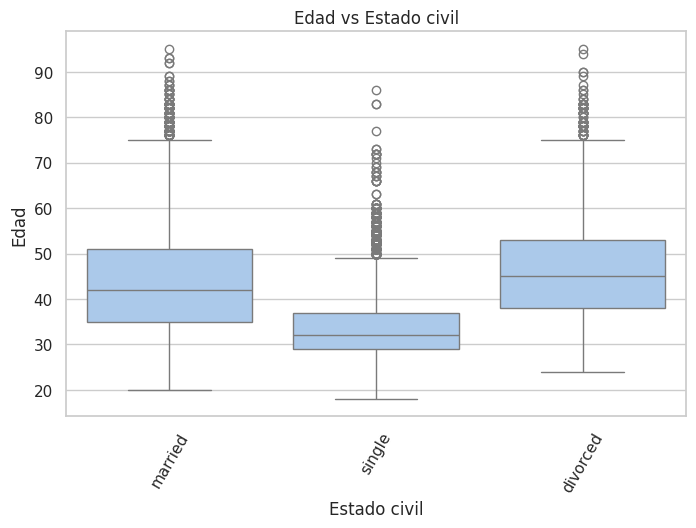

In [31]:
#Grafico Edad vs tipo de trabajo
edad_marital = df01.select('age', 'marital').toPandas()
## El promedio sobre el monto y el tipo de trbajo: se ordena de mayor a menos por monto
## edad_marital = edad_marital.sort_values('avg(age)', ascending=False)
plt.figure(figsize=(8,5))
sns.boxplot(data=edad_marital, x='marital', y='age')
plt.xlabel('Estado civil')
plt.ylabel('Edad')
plt.title('Edad vs Estado civil')
plt.xticks(rotation=60)
plt.show()

### **Comentarios**
- Según la gráfica, se observa que la edad promedio de las personas casadas y divorciadas es mayor y bastante similar entre ambos grupos, mientras que los solteros presentan una edad promedio menor. Este análisis puede ayudar a identificar qué grupo resulta más adecuado para promocionar las suscripciones a depósitos a plazo, ya que, como se observó anteriormente, los solteros tienden a suscribirse en mayor proporción respecto a su cantidad total dentro de la base de datos.

_______________________________________________________________________________________________________________________________________________________

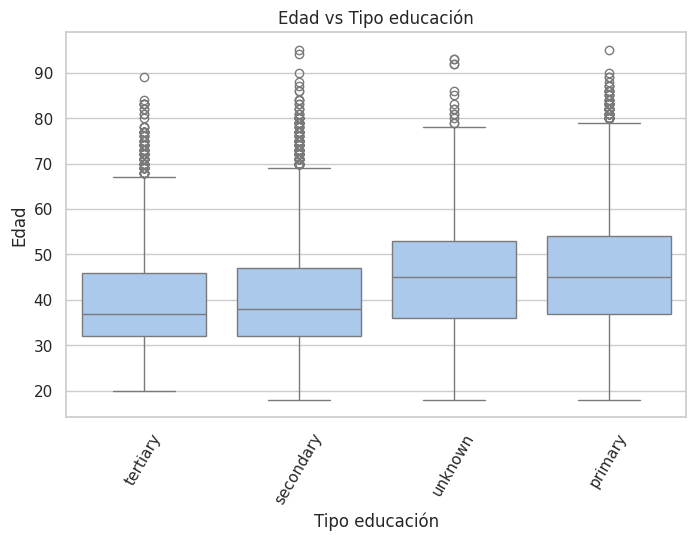

In [32]:
#Grafico Edad vs tipo de trabajo
edad_education = df01.select('age', 'education').toPandas()
## El promedio sobre el monto y el tipo de trbajo: se ordena de mayor a menos por monto
## edad_marital = edad_marital.sort_values('avg(age)', ascending=False)
plt.figure(figsize=(8,5))
sns.boxplot(data=edad_education, x='education', y='age')
plt.xlabel('Tipo educación')
plt.ylabel('Edad')
plt.title('Edad vs Tipo educación')
plt.xticks(rotation=60)
plt.show()

### **Comentarios**
- Se puede apreciar en la gráfica que las personas con educación primaria y educación desconocida presentan una edad promedio entre los 40 y 50 años, mientras que quienes poseen educación secundaria o superior tienen edades promedio entre los 30 y 40 años. Esto podría indicar que las generaciones más jóvenes han tenido mayores oportunidades de acceso a la educación. Asimismo, un mayor nivel educativo podría facilitar la comprensión del funcionamiento de los depósitos a plazo, lo que aumentaría la disposición de estas personas a suscribirse a este tipo de producto financiero.

_______________________________________________________________________________________________________________________________________________________

## **4.- calidad de los Datos:**
- verificación de cantidad de nulos.

In [33]:
for columna in df01.columns:
    cantNulos = df01.where(F.col(columna).isNull()).count()
    print(f"'{columna}' : {cantNulos} valores nulos")

'age' : 0 valores nulos
'job' : 0 valores nulos
'marital' : 0 valores nulos
'education' : 0 valores nulos
'default' : 0 valores nulos
'balance' : 0 valores nulos
'housing' : 0 valores nulos
'loan' : 0 valores nulos
'contact' : 0 valores nulos
'day' : 0 valores nulos
'month' : 0 valores nulos
'duration' : 0 valores nulos
'campaign' : 0 valores nulos
'pdays' : 0 valores nulos
'previous' : 0 valores nulos
'poutcome' : 0 valores nulos
'y' : 0 valores nulos


### **Comentarios**
- En esta sección se ve que las variables no contienen datos nulos, por lo que no es necesario hacer ninguna clase de limpieza a los datos.

## **5.- Preparación de los Datos:**
- PDAYS: .
- Previous: .

In [34]:
noPDAYS = df01.filter(F.col('pdays') == -1).count()
total = df01.select('pdays').count()
porcNoPDAYS = (noPDAYS/total)*100
print(f"Porcentaje de clientes no contactados con anterioridad (Variable PDAYS=-1): {porcNoPDAYS:.2f}%")

Porcentaje de clientes no contactados con anterioridad (Variable PDAYS=-1): 81.74%


### **Comentarios**
- La mayor parte de las personas contactadas no fueron previamente contactadas. Es decir, que casi todos los clientes fueron contactados por primera vez, esto puede explicar porque la mayoria de los contactados no estaban suscritos a un deposito a plazo.

## **6.- Limpieza de Datos:**

In [35]:
df02= df01.filter(F.col('previous')<=30)

In [36]:
df03=df02.drop('pdays')

## **7.- Formato de Datos:**
- Balanceo de aparición de la variable dependiente en los datos.

- 
        - La idea es evitar el skew para la clase de mayor aparición ("no")

In [37]:
dfMayorDependiente = df03.filter(df03['y'] == 'no')
dfMenorDependiente = df03.filter(df03['y'] == 'yes')

cantMayor = dfMayorDependiente.count()

dfOverSampledMinor = dfMenorDependiente.sample(True, cantMayor/dfMenorDependiente.count(), seed=42)

df04 = dfMayorDependiente.union(dfOverSampledMinor)

In [38]:
print(f"el df04 queda (luego del oversampling) = {df04.count()}")

el df04 queda (luego del oversampling) = 80201


In [39]:
totalNw = df04.count()
dfaux = df04.groupBy('y').count()

dfBalance = dfaux.withColumn("Porcentaje", dfaux["count"]*100/totalNw)
dfBalance.show()

+---+-----+-----------------+
|  y|count|       Porcentaje|
+---+-----+-----------------+
| no|39912|49.76496552412065|
|yes|40289|50.23503447587935|
+---+-----+-----------------+



In [40]:
print(f"Canti")

Canti


### **Comentarios**
- Se balancean los datos con el fin de permitir que los datos no se centren solo en las personas que no se han suscrito. esto con el fin de permitir analizar los datos de manera mas completa sin que el valor no de la variable aleatoria canibalice todas las visualizaciones.

## **8.- Codificación para la creación de vector ensamblador para las variables categóricas("features", "target")**
- 

In [41]:
CATEG_col = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']

etapas = []

for colCategorie in CATEG_col:
    indexer = StringIndexer(inputCol=colCategorie, outputCol=colCategorie + 'x')
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[colCategorie + '_oneHot'])
    etapas += [indexer, encoder]

In [42]:
etiqueta = StringIndexer(inputCol='y', outputCol='label', stringOrderType='alphabetAsc')

etapas += [etiqueta]

In [43]:
## Características numéricas

NUMER_col  = ['age', 'balance', 'duration', 'day', 'campaign', 'previous']

entradaEnsamblada = [c + '_oneHot' for c in CATEG_col] + NUMER_col

entradaEnsamblada

['job_oneHot',
 'marital_oneHot',
 'education_oneHot',
 'default_oneHot',
 'housing_oneHot',
 'loan_oneHot',
 'contact_oneHot',
 'poutcome_oneHot',
 'age',
 'balance',
 'duration',
 'day',
 'campaign',
 'previous']

In [44]:
### Tabla de características del vector para entrenamiento de los modelos

VectorEnsamblado = VectorAssembler(inputCols=entradaEnsamblada, outputCol='features')
etapas += [VectorEnsamblado]

In [45]:
##importamos Pipeline de pyspark.ml
from pyspark.ml import Pipeline

In [46]:
### Pipeline para Streaming: ejecución de la transformación del onehotencoder a el vector ensamblado 'features'
pipeline = Pipeline(stages=etapas)
pipelineModel = pipeline.fit(df04)
## Se almacena el pipeline para usar en el streaming o ingesta de datos
pipelineModel.write().overwrite().save(path='modeloPipeline')
df05 = pipelineModel.transform(df04)

### **Comentarios**
- En esta sección se preparan los datos para que los modelos puedan entenderlos y procesarlos correctamente. Se traduce la información del cliente — como su trabajo, estado civil o educación — a un formato numérico, y se guarda ese proceso para poder reutilizarlo fácilmente en el futuro.

In [47]:
df05.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)
 |-- jobx: double (nullable = false)
 |-- job_oneHot: vector (nullable = true)
 |-- maritalx: double (nullable = false)
 |-- marital_oneHot: vector (nullable = true)
 |-- educationx: double (nullable = false)
 |-- education_oneHot: vector (nullable = true)
 |-- defaultx: double (nullable = false)
 |-- default_oneHot: vector (nullable = true)
 |-- housingx: double (nullable = fals

In [48]:
df05.show(5)

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+--------+--------------+-----+-------------+--------+--------------+---------+---------------+-----+--------------------+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|previous|poutcome|  y|jobx|    job_oneHot|maritalx|marital_oneHot|educationx|education_oneHot|defaultx|default_oneHot|housingx|housing_oneHot|loanx|  loan_oneHot|contactx|contact_oneHot|poutcomex|poutcome_oneHot|label|            features|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+--------+--------------+-----+-------------+--------+--------------+---------+---------------+-----

In [49]:
## se crea el Dataframe final para los modelos 
df06 = df05.select("label", "features")

### Se imprime el primer registro para hacer inspección ocular
df06.first()

Row(label=0.0, features=SparseVector(30, {0: 1.0, 11: 1.0, 14: 1.0, 16: 1.0, 18: 1.0, 20: 1.0, 21: 1.0, 24: 58.0, 25: 2143.0, 26: 261.0, 27: 5.0, 28: 1.0}))

In [50]:
df06.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



In [51]:
# Parquet preserves SparseVector structure efficiently
df06.write.mode("overwrite").parquet("output.parquet")

In [52]:
# To read back later
df07 = sparkFonseca.read.parquet("output.parquet")
df07.show(2)

+-----+--------------------+
|label|            features|
+-----+--------------------+
|  0.0|(30,[0,11,14,16,1...|
|  0.0|(30,[2,12,13,16,1...|
+-----+--------------------+
only showing top 2 rows



### **Comentarios**
- Se revisa que el dataset transformado quedó correctamente estructurado, con todas las variables del cliente consolidadas en un único vector de características (features) y la variable objetivo codificada como label.
- Se reduce el dataset a solo esas dos columnas, que son las que realmente necesitan los modelos, y se guarda en disco en formato Parquet para poder reutilizarlo sin tener que repetir todo el proceso de transformación.

## **9.- Modelización: construcción de modelos**

In [53]:
## Se divide el conjunto entrenamiento 80% y prueba 20%
trainData, testData = df07.randomSplit([.8,.2], seed=4321)
## Se revisa la cantidad de datos
print(f"Cantidad del conjunto de datos de entrenamiento: {trainData.count()}")
print(f"Cantidad del conjunto de datos de prueba: {testData.count()}")

Cantidad del conjunto de datos de entrenamiento: 64189
Cantidad del conjunto de datos de prueba: 16012


In [54]:
## Se verifica el balanceo del conjunto de datos de entrenamiento
distroTrain = trainData.groupBy("label").count()
## Visualización de balanceo en porcentaje
distroTrain = distroTrain.withColumn("Porcentaje", distroTrain["count"]*100/trainData.count())
distroTrain.show()

+-----+-----+------------------+
|label|count|        Porcentaje|
+-----+-----+------------------+
|  1.0|32286|50.298337721416445|
|  0.0|31903|49.701662278583555|
+-----+-----+------------------+



In [55]:
## Se verifica el balanceo del conjunto de datos de prueba
distroTest = testData.groupBy("label").count()
## Visualización de balanceo en porcentaje
distroTest = distroTest.withColumn("Porcentaje", distroTest["count"]*100/testData.count())
distroTest.show()

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  1.0| 8003|49.98126405196103|
|  0.0| 8009|50.01873594803897|
+-----+-----+-----------------+



### **Comentarios**
- Se divide el dataset en dos partes: un 80% para entrenar los modelos y un 20% para probarlos. Luego se verifica que ambas partes quedaron balanceadas, es decir, que tienen una proporción similar de clientes que dijeron "sí" y "no" a la suscripción, lo cual es importante para que el modelo no aprenda sesgado hacia una sola clase.

In [56]:
## Función para la matriz de confusión: Gráfica
def plotMatConfusion(confMatrix, subtitulo):
    # Dataframe a pandas
    confMatrixPandas = confMatrix.toPandas()
    # Restructuración para crear la Matrix de Confusión
    confMatrixPivote = confMatrixPandas.pivot(index='label', columns='prediction', values='count').fillna(0)
    # Se grafica la matrix de confusión
    plt.figure(figsize=(5, 5))
    sns.heatmap(confMatrixPivote, annot=True, fmt='g')
    plt.suptitle(subtitulo)
    plt.title('Matriz de Confusión')
    plt.xlabel('Label predicción')
    plt.ylabel('Label')
    plt.show()

In [ ]:
## Función para la ROC: Gráfica
def plotROC(predictions,rocMetric, subtitulo):
    # Obtener las probabilidades previstas para a classe positiva
    probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    # Obtener las etiquetas verdaderas
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    # Calcular la curva ROC usando los datos de las probabilidades de etiquetas verdaderas
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())
    # Se grafica la curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % rocMetric)
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlabel('Proporción de Falsos Positivos')
    plt.ylabel('Proporción de Verdaderos Positivos')
    plt.title('Curva Receiver Operating Characteristic (ROC)')
    plt.suptitle(subtitulo)
    plt.legend(loc='lower right')
    plt.show()

### **Comentarios**
- Se definen dos funciones reutilizables para evaluar visualmente el desempeño de los modelos: una genera la matriz de confusión, que muestra cuántos clientes fueron clasificados correctamente o no, y otra genera la curva ROC, que indica qué tan bien el modelo distingue entre clientes que sí se suscriben y los que no. Estas funciones se usarán más adelante con cada modelo entrenado.

#### **Primer Modelo**: Regresión lineal

##### - **Creación de objeto entrenado**: modelo LR

In [58]:
from pyspark.ml.classification import LogisticRegression
instanciaLR = LogisticRegression(featuresCol='features', labelCol= 'label', maxIter=10)
# Entrenamiento del modelo con Datos de Entrenamiento
modeloLR = instanciaLR.fit(trainData)

26/05/23 21:36:06 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

##### - **Predicción** sobre el objeto entrenado: modelo LR

In [59]:
# Predicción sobre los datos de prueba
predLR = modeloLR.transform(testData)
# se presentan las 10 primeras predicciones del modelo LR
predLR.select("label", "prediction", "probability").show(5)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.78078286731693...|
|  0.0|       0.0|[0.68788562209662...|
|  0.0|       0.0|[0.75721874163524...|
|  0.0|       0.0|[0.84126268755749...|
|  0.0|       0.0|[0.72357387217324...|
+-----+----------+--------------------+
only showing top 5 rows



##### - **Creación del "evaluador"**: Evaluador para métricas de clasificación multiclase

In [60]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [61]:
evaluadorLR = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

##### - **Matrix de Confusión**: modelo LR

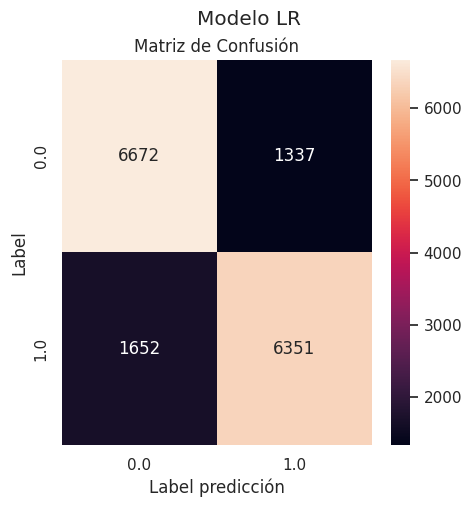

Resultados de Métricas de Rendimiento: Modelo LR
Precision: 0.814 %
Recall:    0.813 %
Accuracy:  0.813 %
f1ScoreLR:  0.813 %


In [62]:
# Se crea la matrix de confusión: predicción en datos de prueba con modelo LR
primerModelo = "Modelo LR"
confMatrixLR = predLR.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixLR, primerModelo)

# Cálculo de las métricas del modelo LR usando el evaluador MultiClase
accuracyLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "accuracy"})
precisionLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedPrecision"})
recallLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedRecall"})
f1ScoreLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "f1"})

# Impresión de las métricas
print(f"Resultados de Métricas de Rendimiento: Modelo LR")
print(f"Precision: {round(precisionLR,3)} %")
print(f"Recall:    {round(recallLR,3)} %")
print(f"Accuracy:  {round(accuracyLR,3)} %")
print(f"f1ScoreLR:  {round(f1ScoreLR,3)} %")

### **Comentarios**
- Se entrena el modelo de Regresión Logística con los datos de entrenamiento y se aplica sobre los datos de prueba para generar las predicciones. Para cada cliente, el modelo calcula la probabilidad de que se suscriba o no al depósito.
- Se evalúa qué tan bien clasificó el modelo. Con una precisión del 81.3%, acierta en más de 8 de cada 10 casos. Sin embargo, la matriz de confusión revela que 1.652 clientes que sí aceptarían la oferta fueron clasificados como negativos, lo que desde el punto de vista del negocio representa oportunidades de venta que se están perdiendo.

##### - **Curva ROC**: modelo LR

In [63]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from sklearn.metrics import roc_curve

0.8922054014361922
areaUnderROC


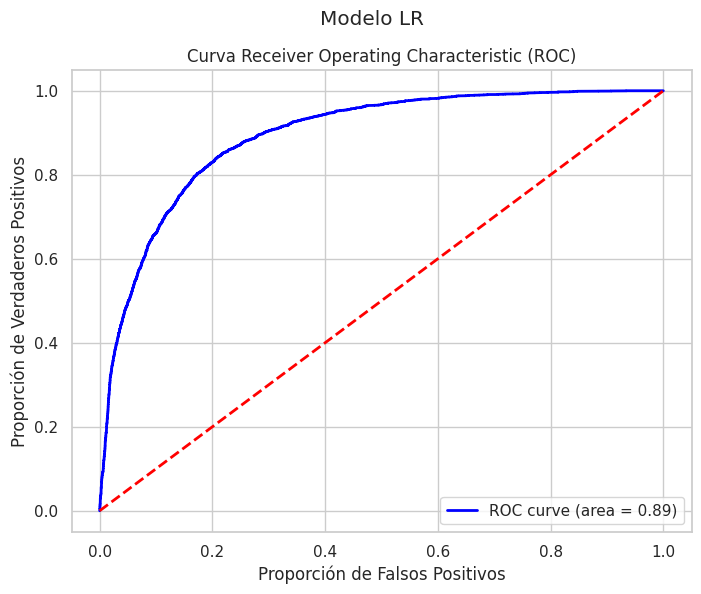

In [64]:
# Se crea un evaluador para métricas de clasificación binaria (área sobre la curva ROC)
evaluadorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocLR = evaluadorBinLR.evaluate(predLR)
print(rocLR)
print(evaluadorBinLR.getMetricName())

plotROC(predLR,rocLR, primerModelo)

### **Comentarios**
- Se calcula y grafica la curva ROC del modelo, obteniendo un área de 0.89. Esto indica que el modelo tiene una muy buena capacidad para distinguir entre clientes que se suscribirán y los que no. Mientras más se aleja la curva de la línea diagonal roja (que representa un modelo aleatorio), mejor es el modelo, y en este caso el resultado es bastante favorable para el negocio.

#### **Segundo Modelo**: Arbol de desición

##### - **Creación de objeto entrenado**: modelo DT

In [65]:
from pyspark.ml.classification import DecisionTreeClassifier
instanciaDT = DecisionTreeClassifier(labelCol= 'label', featuresCol="features")

# Entrenamiento del modelo con Datos de Entrenamiento
modeloDT = instanciaDT.fit(trainData)

##### - **Predicción** sobre el objeto entrenado: modelo DT

In [66]:
# Predicción sobre los datos de prueba
predDT = modeloDT.transform(testData)
# se presentan las 10 primeras predicciones del modelo LR
predDT.select("label", "prediction", "probability").show(10)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.81663625808591...|
|  0.0|       1.0|[0.32423208191126...|
|  0.0|       0.0|[0.81663625808591...|
|  0.0|       1.0|[0.32423208191126...|
|  0.0|       0.0|[0.81663625808591...|
|  0.0|       0.0|[0.81663625808591...|
|  0.0|       0.0|[0.81663625808591...|
|  0.0|       0.0|[0.81663625808591...|
|  0.0|       0.0|[0.81663625808591...|
|  0.0|       0.0|[0.81663625808591...|
+-----+----------+--------------------+
only showing top 10 rows



##### - **Creación del "evaluador"**: Evaluador para métricas de clasificación multiclase

In [67]:
evaluadorDT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

##### - **Matrix de Confusión y Métricas de Rendimiento**: modelo DT

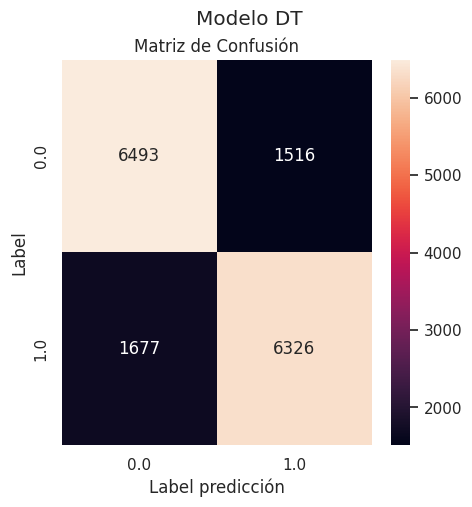

Resultados de Métricas de Rendimiento: Modelo DT
Precision: 0.801 %
Recall:    0.801 %
Accuracy:  0.801 %


In [68]:
# Se crea la matrix de confusión: predicción en datos de prueba con modelo DT
segundoModelo = "Modelo DT"
confMatrixDT = predDT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixDT, segundoModelo)

# Cálculo de las métricas del modelo LR usando el evaluador MultiClase
accuracyDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "accuracy"})
precisionDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedPrecision"})
recallDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedRecall"})
f1ScoreDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "f1"})

# Impresión de las métricas
print(f"Resultados de Métricas de Rendimiento: Modelo DT")
print(f"Precision: {round(precisionDT,3)} %")
print(f"Recall:    {round(recallDT,3)} %")
print(f"Accuracy:  {round(accuracyDT,3)} %")

### **Comentarios**
- Se entrena el segundo modelo usando un Árbol de Decisión y se aplica sobre los datos de prueba. A diferencia de la Regresión Logística, este modelo toma decisiones siguiendo una serie de reglas encadenadas, similar a un diagrama de flujo, lo que lo hace más fácil de interpretar.
- El modelo alcanzó una precisión del 80.1%, ligeramente inferior a la Regresión Logística. La matriz de confusión muestra que 1.677 clientes que sí aceptarían la oferta fueron clasificados como negativos, un resultado muy similar al modelo anterior. En términos de negocio, ambos modelos dejan pasar una cantidad comparable de oportunidades de venta.

##### - **Curva ROC**: modelo DT

0.633173355659002
areaUnderROC


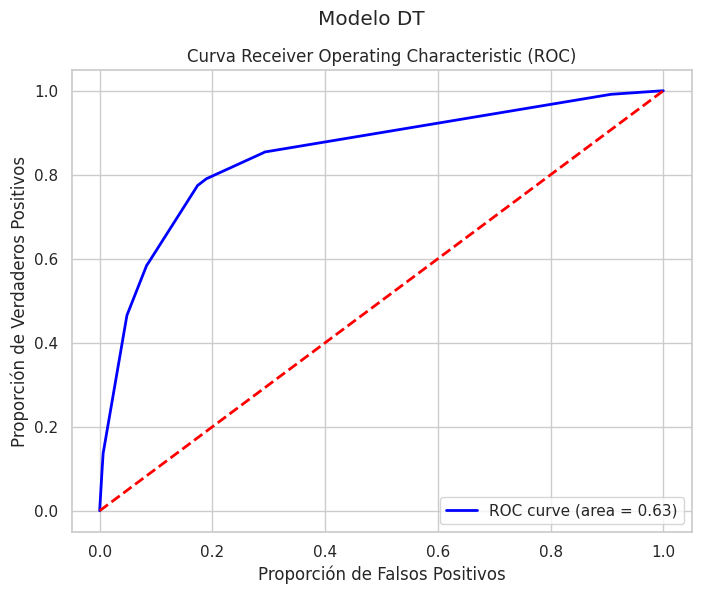

In [69]:
# Se crea un evaluador para métricas de clasificación binaria (área sobre la curva ROC)
evaluadorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocDT = evaluadorBinDT.evaluate(predDT)
print(rocDT)
print(evaluadorBinDT.getMetricName())

plotROC(predDT,rocDT,segundoModelo)

### **Comentarios**
- La curva ROC del Árbol de Decisión obtuvo un área de 0.63, notablemente inferior al 0.89 de la Regresión Logística. Esto indica que este modelo tiene menor capacidad para distinguir entre clientes que se suscribirán y los que no, lo que lo hace menos confiable para apoyar decisiones de la campaña de marketing.

### **10.- Evaluación de modelos**

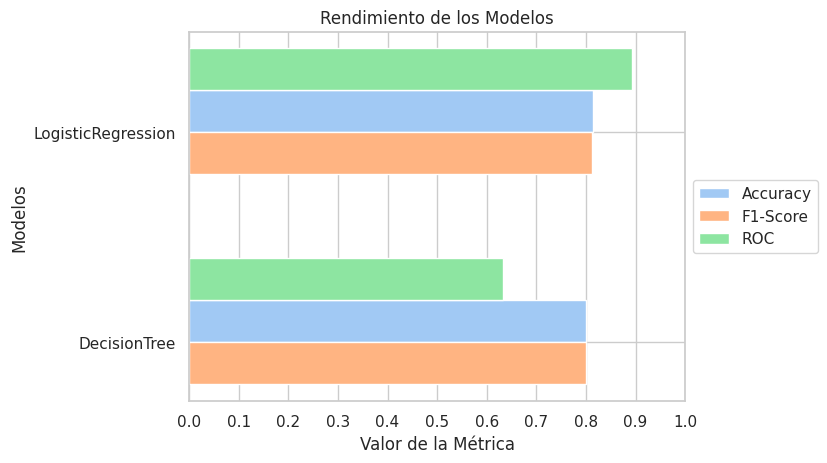

In [70]:
# Datos generales
modelos  = ['LogisticRegression', 'DecisionTree']
accuracy = [accuracyLR, accuracyDT]
f1Score  = [f1ScoreLR, f1ScoreDT]
curvaROC = [rocLR, rocDT]

# Se ordenan los valores según la curva ROC
modelos, f1Score, accuracy, curvaROC = zip(*sorted(zip(modelos, f1Score, accuracy, curvaROC), key=lambda x: x[3]))

# Definición de longitud de barras
longitud = 0.2

# Posición de las barras en horizontal
posHorizontal = np.arange(len(modelos))

# Plotagem do gráfico de barras horizontais
barra1 = plt.barh(posHorizontal + 0.1, accuracy, longitud, label='Accuracy')
barra2 = plt.barh(posHorizontal - 0.1, f1Score, longitud, label='F1-Score')
barra3 = plt.barh(posHorizontal + longitud + 0.1, curvaROC, longitud, label='ROC')

# Configuración del gráfico
plt.ylabel('Modelos')
plt.xlabel('Valor de la Métrica')
plt.title('Rendimiento de los Modelos')
plt.yticks(posHorizontal, modelos)
plt.xticks(np.arange(0, 1.1, 0.1))


# Se agregan las leyendas de métricas
plt.legend(handles=[barra1, barra2, barra3], loc='center left', bbox_to_anchor=(1, 0.5), labels=['Accuracy', 'F1-Score', 'ROC'])

# Se presenta el gráfico
plt.show()

### **Comentarios**
- Se comparan ambos modelos visualmente mediante un gráfico de barras con las tres métricas principales. Si bien los dos modelos tienen una precisión similar (alrededor del 81%), la Regresión Logística supera claramente al Árbol de Decisión en la curva ROC (0.89 vs 0.63), lo que la convierte en la mejor opción para esta campaña. Para el negocio esto es importante, ya que un ROC más alto significa que el modelo identifica de forma más confiable a los clientes con mayor probabilidad de suscribirse, permitiendo enfocar los esfuerzos de marketing de manera más eficiente.

In [ ]:
#sparkFonseca.stop()

### **Conclusiones**
En este taller se trabajó con el dataset de campañas de marketing telefónico de un banco portugués, compuesto por más de 45.000 registros de clientes, con el objetivo de predecir si un cliente aceptaría suscribirse a un depósito a plazo.

El análisis exploratorio reveló un dato importante desde el inicio: el 88.3% de los clientes no se suscribió, lo que muestra que las campañas anteriores tuvieron una efectividad limitada. Adicionalmente, se identificó que la gran mayoría de clientes está al día con sus pagos (solo el 1.8% en mora), lo que sugiere una base de clientes financieramente estable y con potencial para productos de ahorro.
Tras limpiar los datos, eliminar valores atípicos y transformar las variables al formato requerido, se construyó un Pipeline reutilizable que facilita aplicar todo el proceso de preparación sobre nuevos datos en el futuro.

Se entrenaron y evaluaron dos modelos de clasificación. Ambos alcanzaron una precisión cercana al 81%, pero la Regresión Logística fue claramente superior gracias a su curva ROC de 0.89 frente al 0.63 del Árbol de Decisión, demostrando una mejor capacidad para identificar a los clientes con mayor probabilidad de suscribirse.

En conclusión, la Regresión Logística es el modelo recomendado para apoyar futuras campañas, permitiendo al banco enfocar sus esfuerzos en los clientes con mayor potencial y reducir costos. Como mejora futura, sería valioso explorar técnicas de balanceo de clases y modelos más avanzados para reducir los errores en la identificación de clientes positivos.